Imports and config

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = r"C:\Users\aen593\Desktop\network project\dataset\D1.csv"

# -----------------------------
# Windowing
# -----------------------------
WINDOW_SIZE = 100   # cluster 100-row windows instead of single rows

# -----------------------------
# Columns to exclude from clustering
# (kept in final output CSVs)
# -----------------------------
DROP_COLS = [
    "TIME_STAMP",
    "lon",
    "lat",
    "speed",
    "lte_ho_category",
    "nr_ho_category"
]

# Optional: stricter Prognos-like setting
DROP_TPUT = False   # set True if you also want to exclude dl_tput / ul_tput

# -----------------------------
# K selection
# -----------------------------
MACRO_K_CANDIDATES = [2]
MICRO_K_CANDIDATES = [3, 4, 5]
K_SEARCH_SAMPLE_WINDOWS = 1000

# how many farthest micro-clusters per macro become drift
DRIFT_MICRO_PER_MACRO = 1

# -----------------------------
# Base stream size
# Use longest contiguous main-only run automatically
# If you want to cap it, set a number like 400
# -----------------------------
BASE_NUM_WINDOWS = None

# -----------------------------
# Drift schedule (fractions of base stream)
# sudden: switch permanently at this point
# gradual: mixed transition then permanent switch
# recurrent: multiple drift intervals
# -----------------------------
SUDDEN_START_FRAC = 0.35

GRADUAL_START_FRAC = 0.35
GRADUAL_WIDTH_FRAC = 0.20

RECURRENT_WINDOWS_FRAC = [
    (0.25, 0.10),
    (0.55, 0.10),
    (0.80, 0.07)
]

# -----------------------------
# Visualization
# -----------------------------
PLOT_SIGNAL = "lte_serv_rsrp"   # change if you want another signal
SAMPLE_EXPORT_ROWS = 3000       # sample rows around drift region

Load and clean dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
df = df.reset_index(drop=True).copy()
df["_orig_row_id"] = np.arange(len(df))

if DROP_TPUT:
    for c in ["dl_tput", "ul_tput"]:
        if c not in DROP_COLS:
            DROP_COLS.append(c)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (1048575, 27)
Columns: ['TIME_STAMP', 'lon', 'lat', 'speed', 'technology', 'lte_band', 'lte_serv_rsrp', 'lte_serv_rsrq', 'lte_serv_rssi', 'lte_cqi0', 'lte_cqi1', 'nr_band', 'nr_serv_rsrp', 'nr_serv_rsrq', 'nr_serv_sinr', 'nr_cqi', 'dl_tput', 'ul_tput', 'lte_nbr_rsrp', 'lte_nbr_rsrq', 'irat_rsrp', 'irat_rsrq', 'nr_nbr_rsrp', 'nr_nbr_rsrq', 'lte_ho_category', 'nr_ho_category', '_orig_row_id']


,TIME_STAMP,lon,lat,speed,technology,lte_band,lte_serv_rsrp,lte_serv_rsrq,lte_serv_rssi,lte_cqi0,...,ul_tput,lte_nbr_rsrp,lte_nbr_rsrq,irat_rsrp,irat_rsrq,nr_nbr_rsrp,nr_nbr_rsrq,lte_ho_category,nr_ho_category,_orig_row_id
0,07:18.0,-71.052567,42.367088,NaN,LTE,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,no_handover,no_handover,0
1,07:18.3,-71.052567,42.367088,0.0,LTE,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,no_handover,no_handover,1
2,07:18.6,-71.052567,42.367088,0.0,LTE,Band 2,-65.5,-10.44,-36.31,NaN,...,0.0,-75.31,-20.31,NaN,NaN,NaN,NaN,no_handover,no_handover,2
3,07:19.0,-71.052567,42.367088,0.0,LTE,Band 2,-65.5,-10.44,-36.31,NaN,...,0.0,-75.31,-20.31,NaN,NaN,NaN,NaN,no_handover,no_handover,3
4,07:19.3,-71.052567,42.367088,0.0,LTE,Band 2,-65.5,-10.44,-36.31,NaN,...,0.0,-75.31,-20.31,NaN,NaN,NaN,NaN,no_handover,no_handover,4


Prepare feature list


In [3]:
cluster_cols_to_drop = [c for c in DROP_COLS if c in df.columns]
cluster_df = df.drop(columns=cluster_cols_to_drop).copy()

candidate_categorical = ["technology", "lte_band", "nr_band"]
categorical_cols = [c for c in candidate_categorical if c in cluster_df.columns]
numeric_cols = [c for c in cluster_df.columns if c not in categorical_cols + ["_orig_row_id"]]

for c in numeric_cols:
    cluster_df[c] = pd.to_numeric(cluster_df[c], errors="coerce")

print("Dropped from clustering:", cluster_cols_to_drop)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Clustering table shape:", cluster_df.shape)

Dropped from clustering: ['TIME_STAMP', 'lon', 'lat', 'speed', 'lte_ho_category', 'nr_ho_category']
Categorical columns: ['technology', 'lte_band', 'nr_band']
Numeric columns: ['lte_serv_rsrp', 'lte_serv_rsrq', 'lte_serv_rssi', 'lte_cqi0', 'lte_cqi1', 'nr_serv_rsrp', 'nr_serv_rsrq', 'nr_serv_sinr', 'nr_cqi', 'dl_tput', 'ul_tput', 'lte_nbr_rsrp', 'lte_nbr_rsrq', 'irat_rsrp', 'irat_rsrq', 'nr_nbr_rsrp', 'nr_nbr_rsrq']
Clustering table shape: (1048575, 21)


Build 100 row windows

In [4]:
def safe_mode(series):
    m = series.mode(dropna=True)
    if len(m) == 0:
        return np.nan
    return m.iloc[0]

def build_window_summaries(raw_df, feat_df, numeric_cols, categorical_cols, window_size=100):
    n_total = len(raw_df)
    n_windows = n_total // window_size  # drop incomplete tail
    records = []

    for wid in range(n_windows):
        start = wid * window_size
        end = start + window_size

        raw_win = raw_df.iloc[start:end]
        feat_win = feat_df.iloc[start:end]

        rec = {
            "window_id": wid,
            "start_row": start,
            "end_row": end - 1
        }

        # numeric summaries
        for col in numeric_cols:
            s = pd.to_numeric(feat_win[col], errors="coerce")
            rec[f"{col}__mean"] = s.mean()
            rec[f"{col}__std"] = s.std(ddof=0)
            rec[f"{col}__delta"] = s.iloc[-1] - s.iloc[0]

        # categorical summaries
        for col in categorical_cols:
            s = feat_win[col].astype(str)
            rec[f"{col}__mode"] = safe_mode(s)
            rec[f"{col}__nunique"] = s.nunique(dropna=True)

        records.append(rec)

    return pd.DataFrame(records)

window_df = build_window_summaries(
    raw_df=df,
    feat_df=cluster_df,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    window_size=WINDOW_SIZE
)

print("Number of windows:", len(window_df))
display(window_df.head())

Number of windows: 10485


,window_id,start_row,end_row,lte_serv_rsrp__mean,lte_serv_rsrp__std,lte_serv_rsrp__delta,lte_serv_rsrq__mean,lte_serv_rsrq__std,lte_serv_rsrq__delta,lte_serv_rssi__mean,...,nr_nbr_rsrp__delta,nr_nbr_rsrq__mean,nr_nbr_rsrq__std,nr_nbr_rsrq__delta,technology__mode,technology__nunique,lte_band__mode,lte_band__nunique,nr_band__mode,nr_band__nunique
0,0,0,99,-68.742143,0.981217,NaN,-9.423776,0.904731,NaN,-40.294898,...,NaN,NaN,NaN,NaN,LTE,2,Band 2,2,nan,1
1,1,100,199,-67.715200,0.569172,0.57,-9.412600,0.966588,2.00,-39.031800,...,NaN,-15.384324,0.719020,NaN,NSA,1,Band 2,1,n261,2
2,2,200,299,-69.870100,0.881789,-1.38,-10.135800,0.873215,-0.19,-40.816300,...,5.61,-13.897200,0.584963,1.81,NSA,1,Band 2,1,n261,1
3,3,300,399,-70.353700,0.520975,0.81,-10.637700,0.942624,-0.43,-40.709100,...,4.03,-13.587300,0.706187,-0.97,NSA,1,Band 2,1,n261,1
4,4,400,499,-68.205600,0.615684,1.94,-9.589500,1.082541,1.31,-39.599500,...,0.97,-13.282800,0.178214,0.55,NSA,1,Band 2,1,n261,1


Preprocessing pipeline

In [5]:
window_meta_cols = ["window_id", "start_row", "end_row"]
window_cat_cols = [c for c in window_df.columns if c.endswith("__mode")]
window_num_cols = [c for c in window_df.columns if c not in window_meta_cols + window_cat_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

window_preprocessor = ColumnTransformer([
    ("num", num_pipe, window_num_cols),
    ("cat", cat_pipe, window_cat_cols)
])

X_windows = window_preprocessor.fit_transform(window_df)

print("Window feature matrix shape:", X_windows.shape)

Window feature matrix shape: (10485, 60)


Tune and fit macro clusters

In [6]:
def sample_indices(n, size, random_state=42):
    size = min(n, size)
    rng = np.random.default_rng(random_state)
    return rng.choice(n, size=size, replace=False)

def tune_k(X, k_candidates, sample_size=4000, random_state=42):
    idx = sample_indices(X.shape[0], sample_size, random_state)
    Xs = X[idx]

    rows = []
    for k in k_candidates:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_state,
            batch_size=1024,
            n_init=10
        )
        labels = km.fit_predict(Xs)

        if len(np.unique(labels)) < 2:
            sil = -1
        else:
            sil = silhouette_score(Xs, labels)

        rows.append({"k": k, "silhouette": sil})

    return pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)

macro_tuning = tune_k(
    X_windows,
    MACRO_K_CANDIDATES,
    sample_size=K_SEARCH_SAMPLE_WINDOWS,
    random_state=RANDOM_STATE
)

display(macro_tuning)

best_macro_k = int(macro_tuning.iloc[0]["k"])
print("Best macro k:", best_macro_k)

macro_model = MiniBatchKMeans(
    n_clusters=best_macro_k,
    random_state=RANDOM_STATE,
    batch_size=1024,
    n_init=10
)

window_df["macro_cluster"] = macro_model.fit_predict(X_windows)

display(window_df["macro_cluster"].value_counts().sort_index())

,k,silhouette
0,2,0.121528


Best macro k: 2


macro_cluster
0    5808
1    4677
Name: count, dtype: int64

Tune and fit micro clusters inside each macro

In [7]:
window_df["micro_cluster"] = -1

micro_models = {}

for macro_id in sorted(window_df["macro_cluster"].unique()):
    idx = window_df.index[window_df["macro_cluster"] == macro_id].to_numpy()
    X_sub = X_windows[idx]

    tuning = tune_k(
        X_sub,
        MICRO_K_CANDIDATES,
        sample_size=min(K_SEARCH_SAMPLE_WINDOWS, len(idx)),
        random_state=RANDOM_STATE
    )

    best_micro_k = int(tuning.iloc[0]["k"])
    print(f"Macro {macro_id} -> best micro k = {best_micro_k}")
    display(tuning)

    micro_model = MiniBatchKMeans(
        n_clusters=best_micro_k,
        random_state=RANDOM_STATE,
        batch_size=1024,
        n_init=10
    )

    micro_labels = micro_model.fit_predict(X_sub)
    window_df.loc[idx, "micro_cluster"] = micro_labels
    micro_models[macro_id] = micro_model

window_df["micro_name"] = (
    "M" + window_df["macro_cluster"].astype(str) +
    "_m" + window_df["micro_cluster"].astype(str)
)

display(window_df[["window_id", "macro_cluster", "micro_cluster", "micro_name"]].head())

Macro 0 -> best micro k = 3


,k,silhouette
0,3,0.134493
1,5,0.107620
2,4,0.106049


Macro 1 -> best micro k = 3


,k,silhouette
0,3,0.112606
1,4,0.084402
2,5,0.076058


,window_id,macro_cluster,micro_cluster,micro_name
0,0,1,2,M1_m2
1,1,0,1,M0_m1
2,2,0,1,M0_m1
3,3,0,1,M0_m1
4,4,0,1,M0_m1


2D XY projection for plots

In [8]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

macro_ids = sorted(window_df["macro_cluster"].unique())

if len(macro_ids) != 2:
    raise ValueError("This code expects exactly 2 macro clusters.")

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
XY = svd.fit_transform(X_windows)

window_df["x"] = XY[:, 0]
window_df["y"] = XY[:, 1]

display(window_df.head())

,window_id,start_row,end_row,lte_serv_rsrp__mean,lte_serv_rsrp__std,lte_serv_rsrp__delta,lte_serv_rsrq__mean,lte_serv_rsrq__std,lte_serv_rsrq__delta,lte_serv_rssi__mean,...,technology__nunique,lte_band__mode,lte_band__nunique,nr_band__mode,nr_band__nunique,macro_cluster,micro_cluster,micro_name,x,y
0,0,0,99,-68.742143,0.981217,NaN,-9.423776,0.904731,NaN,-40.294898,...,2,Band 2,2,nan,1,1,2,M1_m2,0.162441,2.137412
1,1,100,199,-67.715200,0.569172,0.57,-9.412600,0.966588,2.00,-39.031800,...,1,Band 2,1,n261,2,0,1,M0_m1,3.829526,-3.050190
2,2,200,299,-69.870100,0.881789,-1.38,-10.135800,0.873215,-0.19,-40.816300,...,1,Band 2,1,n261,1,0,1,M0_m1,2.718139,-2.027851
3,3,300,399,-70.353700,0.520975,0.81,-10.637700,0.942624,-0.43,-40.709100,...,1,Band 2,1,n261,1,0,1,M0_m1,2.589480,-2.455758
4,4,400,499,-68.205600,0.615684,1.94,-9.589500,1.082541,1.31,-39.599500,...,1,Band 2,1,n261,1,0,1,M0_m1,2.710459,-1.154039


choose which macro is normal and which is drift

In [9]:
# Set to True if you want to manually choose macro roles
MANUAL_MACRO_ROLE = False

# If MANUAL_MACRO_ROLE = True, set these:
MANUAL_NORMAL_MACRO = 0
MANUAL_DRIFT_MACRO = 1

# get macro centroids in original high-dimensional space
macro_centers = {
    mid: macro_model.cluster_centers_[mid]
    for mid in macro_ids
}

if MANUAL_MACRO_ROLE:
    normal_macro = MANUAL_NORMAL_MACRO
    drift_macro = MANUAL_DRIFT_MACRO
else:
    global_center = np.asarray(X_windows.mean(axis=0)).ravel()
 
    macro_dist_rows = []
    for mid in macro_ids:
        d = np.linalg.norm(macro_centers[mid] - global_center)
        macro_dist_rows.append({
            "macro_cluster": mid,
            "dist_to_global_center": d
        })

    macro_dist_df = pd.DataFrame(macro_dist_rows).sort_values("dist_to_global_center").reset_index(drop=True)

    normal_macro = int(macro_dist_df.iloc[0]["macro_cluster"])
    drift_macro = int(macro_dist_df.iloc[1]["macro_cluster"])

print("normal_macro =", normal_macro)
print("drift_macro  =", drift_macro)

macro_role_map = {
    normal_macro: "normal_macro",
    drift_macro: "drift_macro"
}

window_df["macro_role"] = window_df["macro_cluster"].map(macro_role_map)

normal_macro = 0
drift_macro  = 1


build the global drift axis

In [10]:
normal_center = macro_centers[normal_macro]
drift_center = macro_centers[drift_macro]

axis_vec = drift_center - normal_center
axis_len = np.linalg.norm(axis_vec)

if axis_len == 0:
    raise ValueError("Normal and drift macro centers are identical.")

axis_unit = axis_vec / axis_len

print("axis length =", axis_len)

axis length = 3.5821657681360275


compute ranking for all micro clusters

In [11]:
micro_rows = []

for macro_id in macro_ids:
    micro_model = micro_models[macro_id]
    sub = window_df[window_df["macro_cluster"] == macro_id].copy()

    for micro_id in sorted(sub["micro_cluster"].unique()):
        micro_name = f"M{macro_id}_m{micro_id}"
        center_m = micro_model.cluster_centers_[micro_id]

        # vector from normal macro center to this micro center
        v = center_m - normal_center

        # position along the normal->drift axis
        projection_raw = float(np.dot(v, axis_unit))
        projection_norm = projection_raw / axis_len

        # sideways distance from the axis
        v_side = v - projection_raw * axis_unit
        orthogonal_raw = float(np.linalg.norm(v_side))
        orthogonal_norm = orthogonal_raw / axis_len

        # size
        cluster_size = int((sub["micro_cluster"] == micro_id).sum())

        micro_rows.append({
            "macro_cluster": macro_id,
            "macro_role": macro_role_map[macro_id],
            "micro_cluster": micro_id,
            "micro_name": micro_name,
            "cluster_size": cluster_size,
            "projection_raw": projection_raw,
            "projection_norm": projection_norm,
            "orthogonal_raw": orthogonal_raw,
            "orthogonal_norm": orthogonal_norm
        })

micro_rank_df = pd.DataFrame(micro_rows)

# rank inside each macro by projection on the drift axis
micro_rank_df["rank_in_macro"] = (
    micro_rank_df
    .groupby("macro_cluster")["projection_norm"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

micro_rank_df["n_micros_in_macro"] = (
    micro_rank_df
    .groupby("macro_cluster")["micro_cluster"]
    .transform("count")
)

# global rank across all micro clusters
micro_rank_df = micro_rank_df.sort_values("projection_norm").reset_index(drop=True)
micro_rank_df["global_rank"] = np.arange(1, len(micro_rank_df) + 1)

display(micro_rank_df)

def stage_label(row):
    r = row["rank_in_macro"]
    n = row["n_micros_in_macro"]

    if row["macro_role"] == "normal_macro":
        if r == 1:
            return "core_normal"
        elif r == n:
            return "boundary_normal"
        else:
            return "intermediate_normal"
    else:
        if r == 1:
            return "entry_drift"
        elif r == n:
            return "deep_drift"
        else:
            return "intermediate_drift"

micro_rank_df["stage_label"] = micro_rank_df.apply(stage_label, axis=1)

display(
    micro_rank_df.sort_values(["macro_role", "rank_in_macro"]).reset_index(drop=True)
)   



window_df = window_df.merge(
    micro_rank_df[
        [
            "macro_cluster",
            "macro_role",
            "micro_cluster",
            "micro_name",
            "cluster_size",
            "projection_norm",
            "orthogonal_norm",
            "rank_in_macro",
            "global_rank",
            "stage_label"
        ]
    ],
    on=["macro_cluster", "macro_role", "micro_cluster", "micro_name"],
    how="left"
)

display(window_df.head())

,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank
0,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1
1,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2
2,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3
3,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4
4,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5
5,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6


,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank,stage_label
0,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4,entry_drift
1,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5,intermediate_drift
2,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6,deep_drift
3,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1,core_normal
4,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2,intermediate_normal
5,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3,boundary_normal


,window_id,start_row,end_row,lte_serv_rsrp__mean,lte_serv_rsrp__std,lte_serv_rsrp__delta,lte_serv_rsrq__mean,lte_serv_rsrq__std,lte_serv_rsrq__delta,lte_serv_rssi__mean,...,micro_name,x,y,macro_role,cluster_size,projection_norm,orthogonal_norm,rank_in_macro,global_rank,stage_label
0,0,0,99,-68.742143,0.981217,NaN,-9.423776,0.904731,NaN,-40.294898,...,M1_m2,0.162441,2.137412,drift_macro,2468,0.813538,0.478875,1,4,entry_drift
1,1,100,199,-67.715200,0.569172,0.57,-9.412600,0.966588,2.00,-39.031800,...,M0_m1,3.829526,-3.050190,normal_macro,2484,-0.252390,0.896330,1,1,core_normal
2,2,200,299,-69.870100,0.881789,-1.38,-10.135800,0.873215,-0.19,-40.816300,...,M0_m1,2.718139,-2.027851,normal_macro,2484,-0.252390,0.896330,1,1,core_normal
3,3,300,399,-70.353700,0.520975,0.81,-10.637700,0.942624,-0.43,-40.709100,...,M0_m1,2.589480,-2.455758,normal_macro,2484,-0.252390,0.896330,1,1,core_normal
4,4,400,499,-68.205600,0.615684,1.94,-9.589500,1.082541,1.31,-39.599500,...,M0_m1,2.710459,-1.154039,normal_macro,2484,-0.252390,0.896330,1,1,core_normal


make 2D macro and micro centroids

,macro_cluster,macro_role,x,y
0,0,normal_macro,0.563652,-1.296009
1,1,drift_macro,-0.942032,1.770235


,macro_cluster,macro_role,micro_cluster,micro_name,x,y,rank_in_macro,global_rank,stage_label,projection_norm
0,0,normal_macro,0,M0_m0,-2.719144,-2.631764,2,2,intermediate_normal,0.034231
1,0,normal_macro,1,M0_m1,3.579138,-1.314503,1,1,core_normal,-0.252390
2,0,normal_macro,2,M0_m2,0.698823,0.047514,3,3,boundary_normal,0.198136
3,1,drift_macro,0,M1_m0,-1.781879,2.343557,3,6,deep_drift,1.322614
4,1,drift_macro,1,M1_m1,-3.278316,0.778900,2,5,intermediate_drift,1.122196
5,1,drift_macro,2,M1_m2,0.190650,1.929968,1,4,entry_drift,0.813538


,macro_cluster,macro_role,x,y
0,0,normal_macro,0.563652,-1.296009
1,1,drift_macro,-0.942032,1.770235


,macro_cluster,macro_role,micro_cluster,micro_name,x,y,rank_in_macro,global_rank,stage_label,projection_norm
0,0,normal_macro,0,M0_m0,-2.719144,-2.631764,2,2,intermediate_normal,0.034231
1,0,normal_macro,1,M0_m1,3.579138,-1.314503,1,1,core_normal,-0.252390
2,0,normal_macro,2,M0_m2,0.698823,0.047514,3,3,boundary_normal,0.198136
3,1,drift_macro,0,M1_m0,-1.781879,2.343557,3,6,deep_drift,1.322614
4,1,drift_macro,1,M1_m1,-3.278316,0.778900,2,5,intermediate_drift,1.122196
5,1,drift_macro,2,M1_m2,0.190650,1.929968,1,4,entry_drift,0.813538


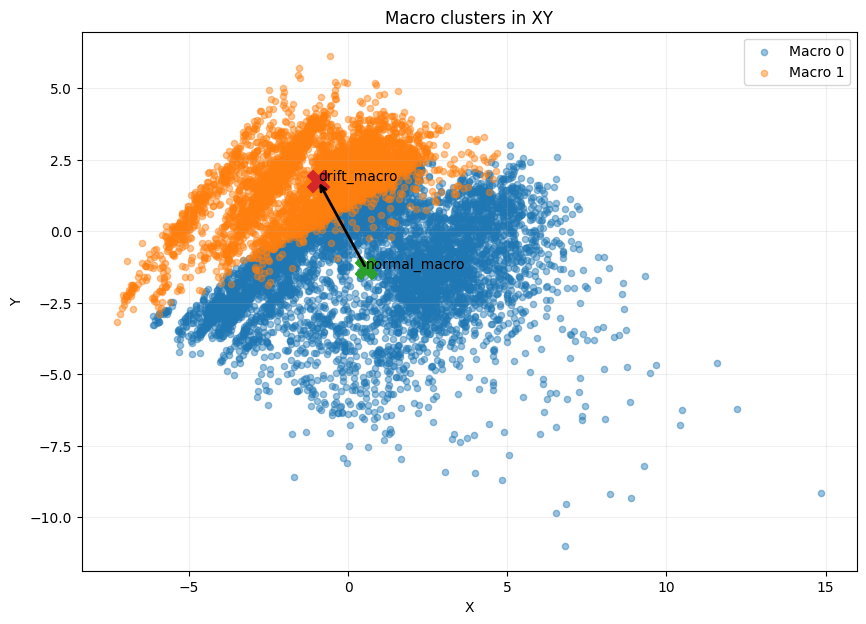

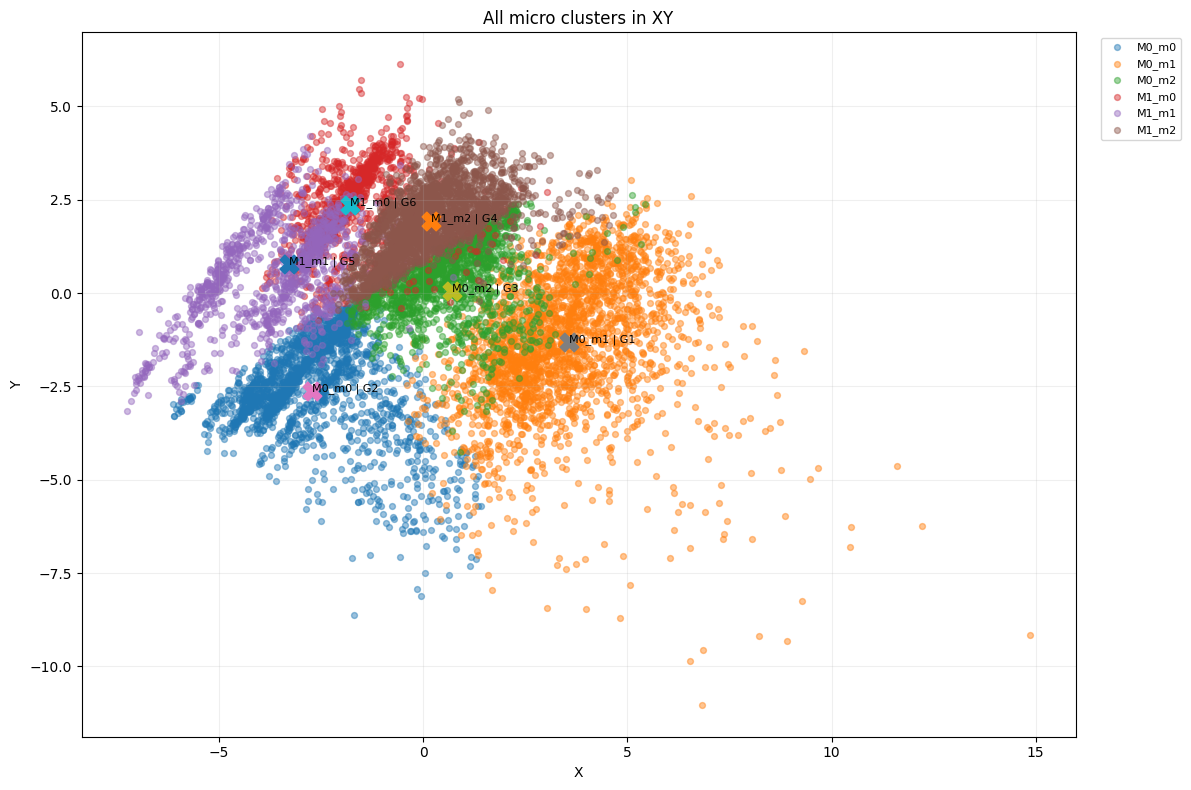

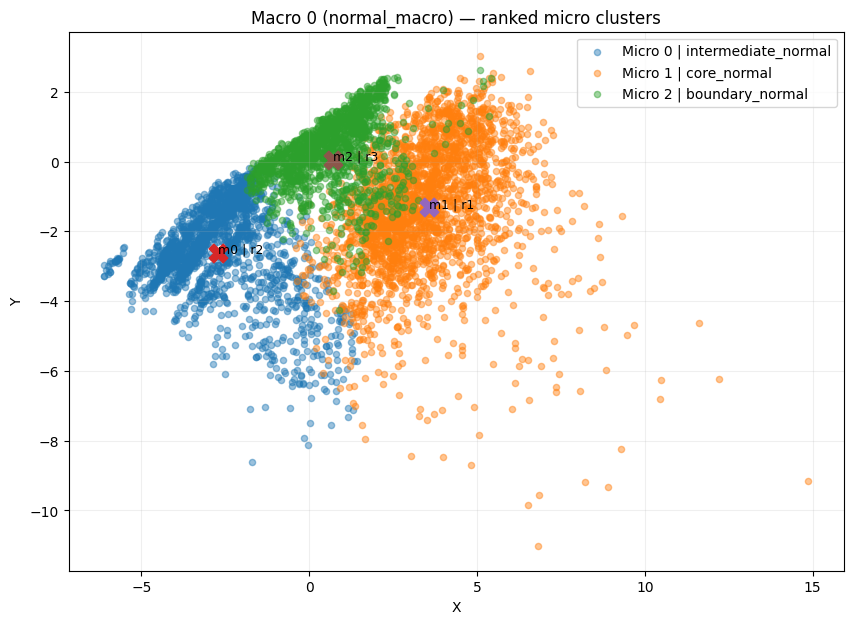

<Figure size 1000x700 with 0 Axes>

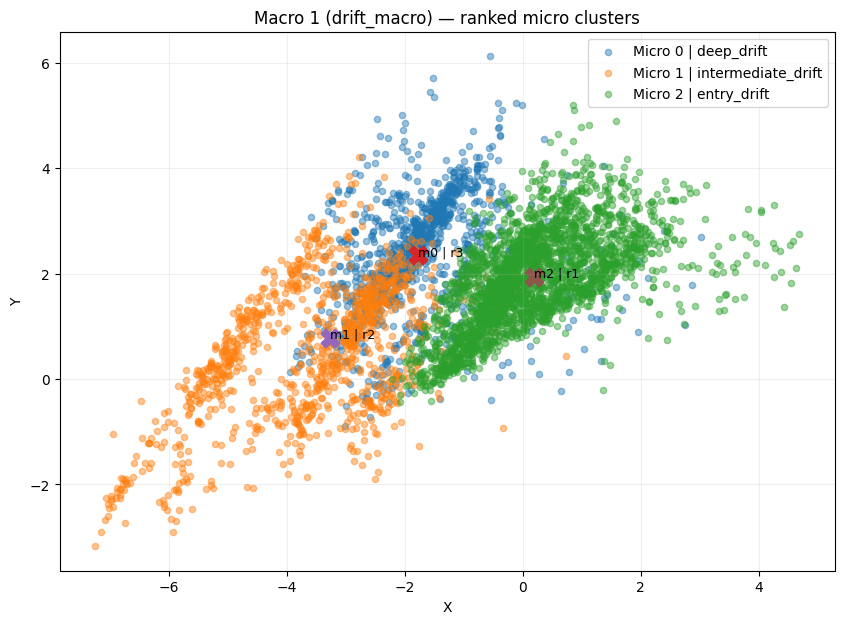

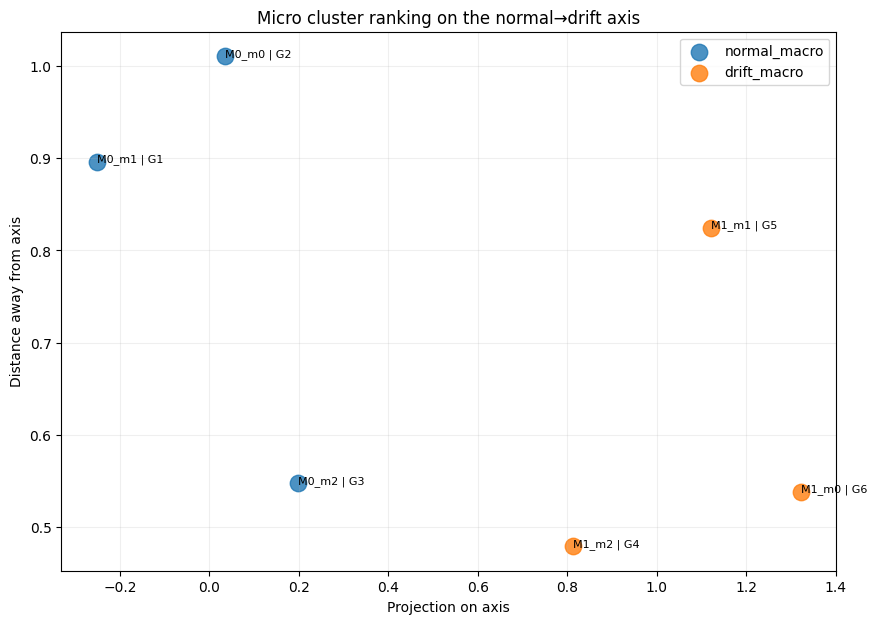

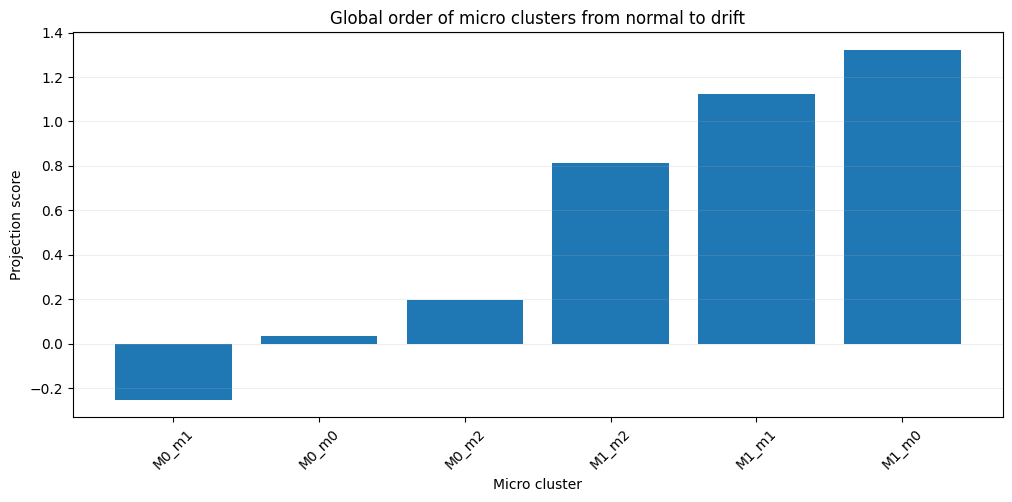

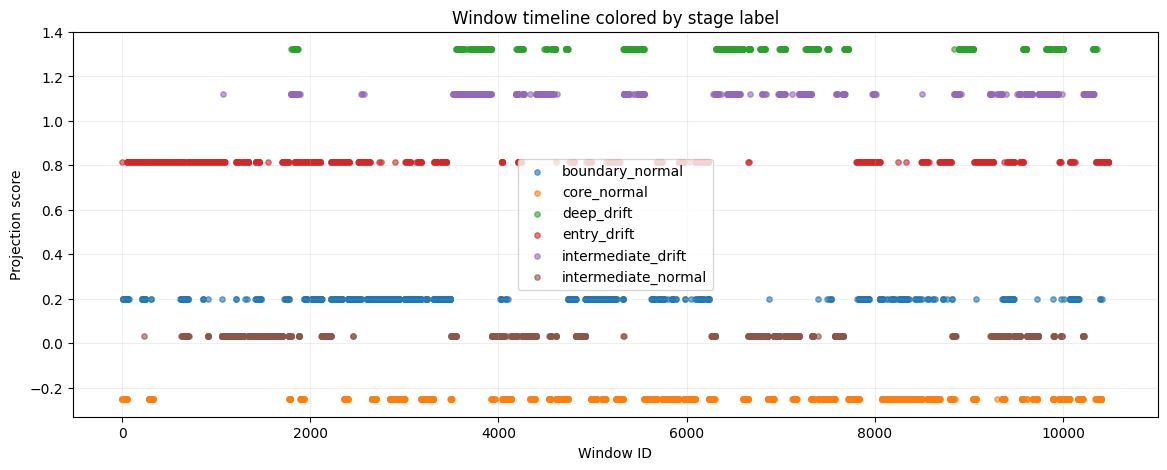

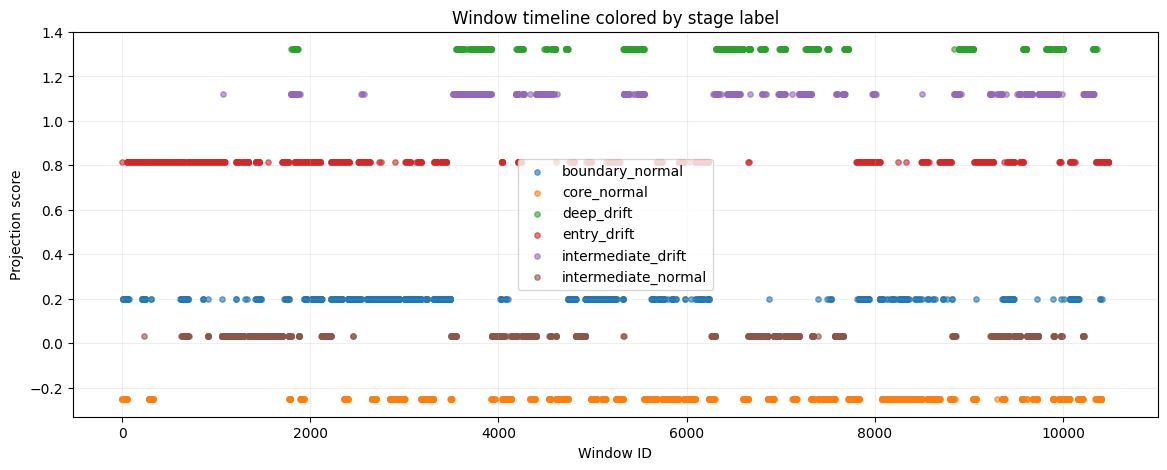

,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank,stage_label
0,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1,core_normal
1,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2,intermediate_normal
2,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3,boundary_normal
3,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4,entry_drift
4,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5,intermediate_drift
5,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6,deep_drift


,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank,stage_label
0,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1,core_normal
1,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2,intermediate_normal
2,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3,boundary_normal
3,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4,entry_drift
4,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5,intermediate_drift
5,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6,deep_drift


In [12]:
# macro centroids in 2D
macro_centers_2d = svd.transform(np.vstack([macro_centers[mid] for mid in macro_ids]))

macro_centers_2d_df = pd.DataFrame({
    "macro_cluster": macro_ids,
    "macro_role": [macro_role_map[mid] for mid in macro_ids],
    "x": macro_centers_2d[:, 0],
    "y": macro_centers_2d[:, 1]
})

# micro centroids in 2D
micro_center_rows = []

for macro_id in macro_ids:
    mm = micro_models[macro_id]
    for micro_id in range(mm.n_clusters):
        center_hd = mm.cluster_centers_[micro_id].reshape(1, -1)
        center_2d = svd.transform(center_hd)[0]

        micro_name = f"M{macro_id}_m{micro_id}"
        rank_row = micro_rank_df[micro_rank_df["micro_name"] == micro_name].iloc[0]

        micro_center_rows.append({
            "macro_cluster": macro_id,
            "macro_role": macro_role_map[macro_id],
            "micro_cluster": micro_id,
            "micro_name": micro_name,
            "x": center_2d[0],
            "y": center_2d[1],
            "rank_in_macro": rank_row["rank_in_macro"],
            "global_rank": rank_row["global_rank"],
            "stage_label": rank_row["stage_label"],
            "projection_norm": rank_row["projection_norm"]
        })

micro_centers_2d_df = pd.DataFrame(micro_center_rows)

display(macro_centers_2d_df)
display(micro_centers_2d_df)



# macro centroids in 2D
macro_centers_2d = svd.transform(np.vstack([macro_centers[mid] for mid in macro_ids]))

macro_centers_2d_df = pd.DataFrame({
    "macro_cluster": macro_ids,
    "macro_role": [macro_role_map[mid] for mid in macro_ids],
    "x": macro_centers_2d[:, 0],
    "y": macro_centers_2d[:, 1]
})

# micro centroids in 2D
micro_center_rows = []

for macro_id in macro_ids:
    mm = micro_models[macro_id]
    for micro_id in range(mm.n_clusters):
        center_hd = mm.cluster_centers_[micro_id].reshape(1, -1)
        center_2d = svd.transform(center_hd)[0]

        micro_name = f"M{macro_id}_m{micro_id}"
        rank_row = micro_rank_df[micro_rank_df["micro_name"] == micro_name].iloc[0]

        micro_center_rows.append({
            "macro_cluster": macro_id,
            "macro_role": macro_role_map[macro_id],
            "micro_cluster": micro_id,
            "micro_name": micro_name,
            "x": center_2d[0],
            "y": center_2d[1],
            "rank_in_macro": rank_row["rank_in_macro"],
            "global_rank": rank_row["global_rank"],
            "stage_label": rank_row["stage_label"],
            "projection_norm": rank_row["projection_norm"]
        })

micro_centers_2d_df = pd.DataFrame(micro_center_rows)

display(macro_centers_2d_df)
display(micro_centers_2d_df)


plt.figure(figsize=(10, 7))

for macro_id in sorted(window_df["macro_cluster"].unique()):
    sub = window_df[window_df["macro_cluster"] == macro_id]
    plt.scatter(sub["x"], sub["y"], s=20, alpha=0.45, label=f"Macro {macro_id}")

for _, row in macro_centers_2d_df.iterrows():
    plt.scatter(row["x"], row["y"], s=250, marker="X")
    plt.text(row["x"], row["y"], f"{row['macro_role']}", fontsize=10)

# arrow from normal to drift macro
nrow = macro_centers_2d_df[macro_centers_2d_df["macro_cluster"] == normal_macro].iloc[0]
drow = macro_centers_2d_df[macro_centers_2d_df["macro_cluster"] == drift_macro].iloc[0]

plt.annotate(
    "",
    xy=(drow["x"], drow["y"]),
    xytext=(nrow["x"], nrow["y"]),
    arrowprops=dict(arrowstyle="->", lw=2)
)

plt.title("Macro clusters in XY")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(alpha=0.2)
plt.show()




plt.figure(figsize=(12, 8))

for micro_name in sorted(window_df["micro_name"].unique()):
    sub = window_df[window_df["micro_name"] == micro_name]
    plt.scatter(sub["x"], sub["y"], s=18, alpha=0.45, label=micro_name)

for _, row in micro_centers_2d_df.iterrows():
    plt.scatter(row["x"], row["y"], s=180, marker="X")
    plt.text(
        row["x"], row["y"],
        f"{row['micro_name']} | G{row['global_rank']}",
        fontsize=8
    )

plt.title("All micro clusters in XY")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


for macro_id in sorted(window_df["macro_cluster"].unique()):
    sub_macro = window_df[window_df["macro_cluster"] == macro_id].copy()
    sub_centers = micro_centers_2d_df[micro_centers_2d_df["macro_cluster"] == macro_id].copy()

    plt.figure(figsize=(10, 7))

    for micro_id in sorted(sub_macro["micro_cluster"].unique()):
        sub_micro = sub_macro[sub_macro["micro_cluster"] == micro_id]
        stage = sub_micro["stage_label"].iloc[0]

        plt.scatter(
            sub_micro["x"],
            sub_micro["y"],
            s=20,
            alpha=0.45,
            label=f"Micro {micro_id} | {stage}"
        )

    for _, row in sub_centers.iterrows():
        plt.scatter(row["x"], row["y"], s=180, marker="X")
        plt.text(
            row["x"], row["y"],
            f"m{row['micro_cluster']} | r{row['rank_in_macro']}",
            fontsize=9
        )

    role_here = sub_macro["macro_role"].iloc[0]

    plt.title(f"Macro {macro_id} ({role_here}) — ranked micro clusters")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()




    plt.figure(figsize=(10, 7))

for role in ["normal_macro", "drift_macro"]:
    sub = micro_rank_df[micro_rank_df["macro_role"] == role]
    plt.scatter(
        sub["projection_norm"],
        sub["orthogonal_norm"],
        s=140,
        alpha=0.8,
        label=role
    )

for _, row in micro_rank_df.iterrows():
    plt.text(
        row["projection_norm"],
        row["orthogonal_norm"],
        f"{row['micro_name']} | G{row['global_rank']}",
        fontsize=8
    )

plt.title("Micro cluster ranking on the normal→drift axis")
plt.xlabel("Projection on axis")
plt.ylabel("Distance away from axis")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



plot_df = micro_rank_df.sort_values("global_rank").copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["micro_name"], plot_df["projection_norm"])
plt.xticks(rotation=45)
plt.title("Global order of micro clusters from normal to drift")
plt.xlabel("Micro cluster")
plt.ylabel("Projection score")
plt.grid(axis="y", alpha=0.2)
plt.show()


plt.figure(figsize=(14, 5))

for stage in sorted(window_df["stage_label"].unique()):
    sub = window_df[window_df["stage_label"] == stage]
    plt.scatter(
        sub["window_id"],
        sub["projection_norm"],
        s=15,
        alpha=0.6,
        label=stage
    )

plt.title("Window timeline colored by stage label")
plt.xlabel("Window ID")
plt.ylabel("Projection score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(14, 5))

for stage in sorted(window_df["stage_label"].unique()):
    sub = window_df[window_df["stage_label"] == stage]
    plt.scatter(
        sub["window_id"],
        sub["projection_norm"],
        s=15,
        alpha=0.6,
        label=stage
    )

plt.title("Window timeline colored by stage label")
plt.xlabel("Window ID")
plt.ylabel("Projection score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

rank_in_macro_df = micro_rank_df.sort_values(
    ["macro_cluster", "rank_in_macro"]
).reset_index(drop=True)

display(rank_in_macro_df)

global_rank_df = micro_rank_df.sort_values("global_rank").reset_index(drop=True)
display(global_rank_df)


Output

In [14]:
WINDOW_OUTPUT_CSV = "window_ranking_output.csv"
MICRO_OUTPUT_CSV = "micro_cluster_ranking_output.csv"
STAGE_SUMMARY_CSV = "window_stage_summary.csv"

micro_rank_df.to_csv(MICRO_OUTPUT_CSV, index=False)
window_df.to_csv(WINDOW_OUTPUT_CSV, index=False)

stage_summary_df = (
    window_df.groupby(
        ["macro_cluster", "macro_role", "micro_cluster", "micro_name", "rank_in_macro", "global_rank", "stage_label"],
        as_index=False
    )
    .agg(
        n_windows=("window_id", "count"),
        mean_projection=("projection_norm", "mean"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean")
    )
    .sort_values(["global_rank", "rank_in_macro"])
)

stage_summary_df.to_csv(STAGE_SUMMARY_CSV, index=False)

# =========================================================
# 9) PRINT FINAL TABLES
# =========================================================
print("\nSaved CSV files:")
print(" -", MICRO_OUTPUT_CSV)
print(" -", WINDOW_OUTPUT_CSV)
print(" -", STAGE_SUMMARY_CSV)

print("\nMicro cluster ranking:")
display(micro_rank_df.sort_values(["global_rank"]).reset_index(drop=True))

print("\nWindow stage summary:")
display(stage_summary_df.reset_index(drop=True))

print("\nStage counts:")
display(window_df["stage_label"].value_counts())
micro_rank_df.to_csv(MICRO_OUTPUT_CSV, index=False)
window_df.to_csv(WINDOW_OUTPUT_CSV, index=False)

stage_summary_df = (
    window_df.groupby(
        ["macro_cluster", "macro_role", "micro_cluster", "micro_name", "rank_in_macro", "global_rank", "stage_label"],
        as_index=False
    )
    .agg(
        n_windows=("window_id", "count"),
        mean_projection=("projection_norm", "mean"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean")
    )
    .sort_values(["global_rank", "rank_in_macro"])
)

stage_summary_df.to_csv(STAGE_SUMMARY_CSV, index=False)

# =========================================================
# 9) PRINT FINAL TABLES
# =========================================================
print("\nSaved CSV files:")
print(" -", MICRO_OUTPUT_CSV)
print(" -", WINDOW_OUTPUT_CSV)
print(" -", STAGE_SUMMARY_CSV)

print("\nMicro cluster ranking:")
display(micro_rank_df.sort_values(["global_rank"]).reset_index(drop=True))

print("\nWindow stage summary:")
display(stage_summary_df.reset_index(drop=True))

print("\nStage counts:")
display(window_df["stage_label"].value_counts())


Saved CSV files:
 - micro_cluster_ranking_output.csv
 - window_ranking_output.csv
 - window_stage_summary.csv

Micro cluster ranking:


,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank,stage_label
0,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1,core_normal
1,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2,intermediate_normal
2,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3,boundary_normal
3,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4,entry_drift
4,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5,intermediate_drift
5,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6,deep_drift



Window stage summary:


,macro_cluster,macro_role,micro_cluster,micro_name,rank_in_macro,global_rank,stage_label,n_windows,mean_projection,mean_x,mean_y
0,0,normal_macro,1,M0_m1,1,1,core_normal,2484,-0.252390,3.461624,-1.326053
1,0,normal_macro,0,M0_m0,2,2,intermediate_normal,1855,0.034231,-2.638744,-2.591418
2,0,normal_macro,2,M0_m2,3,3,boundary_normal,1469,0.198136,0.640847,0.279625
3,1,drift_macro,2,M1_m2,1,4,entry_drift,2468,0.813538,0.179188,1.896100
4,1,drift_macro,1,M1_m1,2,5,intermediate_drift,1105,1.122196,-3.613213,0.534574
5,1,drift_macro,0,M1_m0,3,6,deep_drift,1104,1.322614,-1.715436,2.350325



Stage counts:


...

,macro_cluster,macro_role,micro_cluster,micro_name,cluster_size,projection_raw,projection_norm,orthogonal_raw,orthogonal_norm,rank_in_macro,n_micros_in_macro,global_rank,stage_label
0,0,normal_macro,1,M0_m1,2484,-0.904102,-0.252390,3.210802,0.896330,1,3,1,core_normal
1,0,normal_macro,0,M0_m0,1855,0.122622,0.034231,3.621040,1.010852,2,3,2,intermediate_normal
2,0,normal_macro,2,M0_m2,1469,0.709755,0.198136,1.961262,0.547507,3,3,3,boundary_normal
3,1,drift_macro,2,M1_m2,2468,2.914229,0.813538,1.715410,0.478875,1,3,4,entry_drift
4,1,drift_macro,1,M1_m1,1105,4.019894,1.122196,2.954507,0.824782,2,3,5,intermediate_drift
5,1,drift_macro,0,M1_m0,1104,4.737824,1.322614,1.927637,0.538120,3,3,6,deep_drift



Window stage summary:


,macro_cluster,macro_role,micro_cluster,micro_name,rank_in_macro,global_rank,stage_label,n_windows,mean_projection,mean_x,mean_y
0,0,normal_macro,1,M0_m1,1,1,core_normal,2484,-0.252390,3.461624,-1.326053
1,0,normal_macro,0,M0_m0,2,2,intermediate_normal,1855,0.034231,-2.638744,-2.591418
2,0,normal_macro,2,M0_m2,3,3,boundary_normal,1469,0.198136,0.640847,0.279625
3,1,drift_macro,2,M1_m2,1,4,entry_drift,2468,0.813538,0.179188,1.896100
4,1,drift_macro,1,M1_m1,2,5,intermediate_drift,1105,1.122196,-3.613213,0.534574
5,1,drift_macro,0,M1_m0,3,6,deep_drift,1104,1.322614,-1.715436,2.350325



Stage counts:


stage_label
core_normal            2484
entry_drift            2468
intermediate_normal    1855
boundary_normal        1469
intermediate_drift     1105
deep_drift             1104
Name: count, dtype: int64

In [13]:
import numpy as np
import pandas as pd

# =========================================================
# SETTINGS
# =========================================================
BASE_NUM_WINDOWS = 200      # set None to use the longest contiguous normal run
SUDDEN_START_FRAC = 0.40

GRADUAL_START_FRAC = 0.35
GRADUAL_WIDTH_FRAC = 0.30   # transition width as fraction of baseline windows

# recurrent intervals as (start_frac, width_frac)
RECURRENT_WINDOWS_FRAC = [
    (0.25, 0.10),
    (0.55, 0.10),
    (0.80, 0.08),
]

# output files
BASE_CSV = "base_normal_reference.csv"
SUDDEN_CSV = "sudden_drift.csv"
GRADUAL_CSV = "gradual_drift.csv"
RECURRENT_CSV = "recurrent_drift.csv"

# =========================================================
# CHECKS
# =========================================================
required_window_cols = {"window_id", "macro_role", "stage_label"}
missing = required_window_cols - set(window_df.columns)
if missing:
    raise ValueError(f"window_df is missing required columns: {missing}")

if len(df) < WINDOW_SIZE:
    raise ValueError("df is smaller than one window.")

# make safe copies
df = df.copy().reset_index(drop=True)
window_df = window_df.copy().sort_values("window_id").reset_index(drop=True)

# keep a stable original row id if it doesn't already exist
if "_orig_row_id" not in df.columns:
    df["_orig_row_id"] = np.arange(len(df))

# =========================================================
# HELPERS
# =========================================================
normal_stages = ["core_normal", "intermediate_normal", "boundary_normal"]
drift_stages = ["entry_drift", "intermediate_drift", "deep_drift"]

stage_to_windows = {
    stage: window_df.loc[window_df["stage_label"] == stage, "window_id"].tolist()
    for stage in normal_stages + drift_stages
}

window_meta = window_df.set_index("window_id")[["macro_role", "stage_label", "micro_name"]].to_dict("index")

def longest_true_run(mask):
    best_start, best_len = 0, 0
    cur_start, cur_len = None, 0

    for i, val in enumerate(mask):
        if val:
            if cur_start is None:
                cur_start = i
                cur_len = 1
            else:
                cur_len += 1
        else:
            if cur_start is not None and cur_len > best_len:
                best_start, best_len = cur_start, cur_len
            cur_start, cur_len = None, 0

    if cur_start is not None and cur_len > best_len:
        best_start, best_len = cur_start, cur_len

    return best_start, best_len

def get_raw_window_rows(raw_df, window_id, window_size):
    s = int(window_id) * window_size
    e = s + window_size
    return raw_df.iloc[s:e].copy().reset_index(drop=True)

# boundary-matching columns to reduce artificial jumps
candidate_boundary_cols = [
    "lte_serv_rsrp", "lte_serv_rsrq", "lte_serv_rssi",
    "nr_serv_rsrp", "nr_serv_rsrq", "nr_serv_sinr",
    "dl_tput", "ul_tput",
    "lte_nbr_rsrp", "nr_nbr_rsrp",
    "irat_rsrp", "irat_rsrq"
]
boundary_cols = [c for c in candidate_boundary_cols if c in df.columns]

if len(boundary_cols) == 0:
    raise ValueError("No numeric boundary columns found for continuity matching.")

window_start_vec = {}
window_end_vec = {}

for wid in window_df["window_id"]:
    chunk = get_raw_window_rows(df, wid, WINDOW_SIZE)
    start_vec = pd.to_numeric(chunk.iloc[0][boundary_cols], errors="coerce").astype(float).to_numpy()
    end_vec = pd.to_numeric(chunk.iloc[-1][boundary_cols], errors="coerce").astype(float).to_numpy()
    window_start_vec[int(wid)] = start_vec
    window_end_vec[int(wid)] = end_vec

def mse_ignore_nan(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if not mask.any():
        return 0.0
    return float(np.mean((a[mask] - b[mask]) ** 2))

def resolve_stage_pool(stage_name):
    """
    Fallbacks keep generation robust if one stage is empty.
    """
    fallback_map = {
        "core_normal": ["core_normal", "intermediate_normal", "boundary_normal"],
        "intermediate_normal": ["intermediate_normal", "boundary_normal", "core_normal"],
        "boundary_normal": ["boundary_normal", "intermediate_normal", "core_normal"],
        "entry_drift": ["entry_drift", "intermediate_drift", "deep_drift"],
        "intermediate_drift": ["intermediate_drift", "entry_drift", "deep_drift"],
        "deep_drift": ["deep_drift", "intermediate_drift", "entry_drift"],
    }
    for s in fallback_map[stage_name]:
        ids = stage_to_windows.get(s, [])
        if len(ids) > 0:
            return ids, s
    raise ValueError(f"No candidate windows available for stage {stage_name} or its fallbacks.")

def choose_best_window(candidate_ids, prev_final_window_id=None, next_base_window_id=None, used_ids=None):
    used_ids = set() if used_ids is None else set(used_ids)

    available = [wid for wid in candidate_ids if wid not in used_ids]
    if len(available) == 0:
        available = list(candidate_ids)

    prev_end = window_end_vec.get(prev_final_window_id, None)
    next_start = window_start_vec.get(next_base_window_id, None)

    best_id = None
    best_score = np.inf

    for wid in available:
        score = 0.0
        if prev_end is not None:
            score += mse_ignore_nan(window_start_vec[wid], prev_end)
        if next_start is not None:
            score += mse_ignore_nan(window_end_vec[wid], next_start)

        if score < best_score:
            best_score = score
            best_id = wid

    return best_id

def materialize_stream(raw_df, selected_window_ids, selected_source_types, selected_source_stages, stream_name):
    parts = []

    for pos, (wid, src_type, src_stage) in enumerate(zip(selected_window_ids, selected_source_types, selected_source_stages)):
        chunk = get_raw_window_rows(raw_df, wid, WINDOW_SIZE)
        meta = window_meta[int(wid)]

        chunk["stream_name"] = stream_name
        chunk["stream_window_pos"] = pos
        chunk["source_window_id"] = int(wid)
        chunk["source_window_type"] = src_type         # base or injected
        chunk["source_stage_label"] = src_stage
        chunk["source_macro_role"] = meta["macro_role"]
        chunk["source_micro_name"] = meta.get("micro_name", None)

        parts.append(chunk)

    out = pd.concat(parts, ignore_index=True)
    out["stream_row_id"] = np.arange(len(out))
    return out

def build_stream_from_plan(raw_df, base_window_ids, stage_plan, stream_name):
    """
    stage_plan: list of same length as base_window_ids
      - None => keep original base window
      - stage label string => replace with a window drawn from that stage
    """
    selected_window_ids = []
    selected_source_types = []
    selected_source_stages = []
    used_injected = set()

    for i, (base_wid, desired_stage) in enumerate(zip(base_window_ids, stage_plan)):
        if desired_stage is None:
            selected_window_ids.append(int(base_wid))
            selected_source_types.append("base")
            selected_source_stages.append(window_meta[int(base_wid)]["stage_label"])
            continue

        candidate_ids, resolved_stage = resolve_stage_pool(desired_stage)

        prev_final_window_id = selected_window_ids[-1] if len(selected_window_ids) > 0 else None

        next_base_window_id = None
        for j in range(i + 1, len(base_window_ids)):
            if stage_plan[j] is None:
                next_base_window_id = int(base_window_ids[j])
                break

        chosen = choose_best_window(
            candidate_ids=candidate_ids,
            prev_final_window_id=prev_final_window_id,
            next_base_window_id=next_base_window_id,
            used_ids=used_injected
        )

        used_injected.add(int(chosen))
        selected_window_ids.append(int(chosen))
        selected_source_types.append("injected")
        selected_source_stages.append(resolved_stage)

    return materialize_stream(raw_df, selected_window_ids, selected_source_types, selected_source_stages, stream_name)

# =========================================================
# 1) BUILD ONE SHARED NORMAL BASELINE
# =========================================================
normal_mask = window_df["stage_label"].isin(normal_stages).to_numpy()
base_start_idx, longest_len = longest_true_run(normal_mask)

if longest_len == 0:
    raise ValueError("No contiguous normal run found in window_df.")

if BASE_NUM_WINDOWS is None:
    use_len = longest_len
else:
    use_len = min(BASE_NUM_WINDOWS, longest_len)

base_block = window_df.iloc[base_start_idx:base_start_idx + use_len].copy()
base_window_ids = base_block["window_id"].tolist()

print(f"Baseline starts at window {base_window_ids[0]} and uses {len(base_window_ids)} windows ({len(base_window_ids) * WINDOW_SIZE} rows).")

base_stream = materialize_stream(
    raw_df=df,
    selected_window_ids=base_window_ids,
    selected_source_types=["base"] * len(base_window_ids),
    selected_source_stages=[window_meta[int(w)]["stage_label"] for w in base_window_ids],
    stream_name="base_normal_reference"
)

# =========================================================
# 2) BUILD STAGE PLANS ON THE SAME BASELINE
# =========================================================
n_base = len(base_window_ids)

# ---- sudden drift: jump from base to stronger drift
sudden_start = int(round(SUDDEN_START_FRAC * n_base))
sudden_plan = [None] * n_base
for i in range(sudden_start, n_base):
    sudden_plan[i] = "deep_drift"

# ---- gradual drift: boundary_normal -> entry_drift -> intermediate_drift -> deep_drift
gradual_start = int(round(GRADUAL_START_FRAC * n_base))
gradual_width = max(4, int(round(GRADUAL_WIDTH_FRAC * n_base)))
gradual_end = min(n_base, gradual_start + gradual_width)

gradual_plan = [None] * n_base
transition_len = gradual_end - gradual_start

if transition_len > 0:
    q1 = gradual_start + max(1, transition_len // 4)
    q2 = gradual_start + max(2, transition_len // 2)
    q3 = gradual_start + max(3, (3 * transition_len) // 4)

    for i in range(gradual_start, min(q1, n_base)):
        gradual_plan[i] = "boundary_normal"
    for i in range(min(q1, n_base), min(q2, n_base)):
        gradual_plan[i] = "entry_drift"
    for i in range(min(q2, n_base), min(q3, n_base)):
        gradual_plan[i] = "intermediate_drift"
    for i in range(min(q3, n_base), gradual_end):
        gradual_plan[i] = "deep_drift"

for i in range(gradual_end, n_base):
    gradual_plan[i] = "deep_drift"

# ---- recurrent drift: alternating drift intervals on the same baseline
recurrent_plan = [None] * n_base
recurrent_stage_cycle = ["entry_drift", "intermediate_drift", "entry_drift", "deep_drift"]

for k, (start_frac, width_frac) in enumerate(RECURRENT_WINDOWS_FRAC):
    s = int(round(start_frac * n_base))
    w = max(1, int(round(width_frac * n_base)))
    e = min(n_base, s + w)

    stage_here = recurrent_stage_cycle[k % len(recurrent_stage_cycle)]
    for i in range(s, e):
        recurrent_plan[i] = stage_here

# =========================================================
# 3) MATERIALIZE STREAMS
# =========================================================
sudden_stream = build_stream_from_plan(df, base_window_ids, sudden_plan, "sudden_drift")
gradual_stream = build_stream_from_plan(df, base_window_ids, gradual_plan, "gradual_drift")
recurrent_stream = build_stream_from_plan(df, base_window_ids, recurrent_plan, "recurrent_drift")

# =========================================================
# 4) SAVE CSV OUTPUTS
# =========================================================
base_stream.to_csv(BASE_CSV, index=False)
sudden_stream.to_csv(SUDDEN_CSV, index=False)
gradual_stream.to_csv(GRADUAL_CSV, index=False)
recurrent_stream.to_csv(RECURRENT_CSV, index=False)

print("\nSaved:")
print(" -", BASE_CSV)
print(" -", SUDDEN_CSV)
print(" -", GRADUAL_CSV)
print(" -", RECURRENT_CSV)

# =========================================================
# 5) SMALL SUMMARY TABLE
# =========================================================
summary_df = pd.DataFrame({
    "stream_name": ["base_normal_reference", "sudden_drift", "gradual_drift", "recurrent_drift"],
    "n_rows": [len(base_stream), len(sudden_stream), len(gradual_stream), len(recurrent_stream)],
    "n_windows": [len(base_window_ids)] * 4,
    "n_injected_windows": [
        int((base_stream["source_window_type"] == "injected").sum() / WINDOW_SIZE),
        int((sudden_stream["source_window_type"] == "injected").sum() / WINDOW_SIZE),
        int((gradual_stream["source_window_type"] == "injected").sum() / WINDOW_SIZE),
        int((recurrent_stream["source_window_type"] == "injected").sum() / WINDOW_SIZE),
    ]
})

display(summary_df)

print("\nBase window source stages:")
display(base_stream[["stream_window_pos", "source_window_id", "source_stage_label"]].drop_duplicates().head(20))

print("\nSudden drift window source stages:")
display(sudden_stream[["stream_window_pos", "source_window_id", "source_window_type", "source_stage_label"]].drop_duplicates().head(30))

print("\nGradual drift window source stages:")
display(gradual_stream[["stream_window_pos", "source_window_id", "source_window_type", "source_stage_label"]].drop_duplicates().head(40))

print("\nRecurrent drift window source stages:")
display(recurrent_stream[["stream_window_pos", "source_window_id", "source_window_type", "source_stage_label"]].drop_duplicates().head(40))

Baseline starts at window 8057 and uses 186 windows (18600 rows).

Saved:
 - base_normal_reference.csv
 - sudden_drift.csv
 - gradual_drift.csv
 - recurrent_drift.csv


,stream_name,n_rows,n_windows,n_injected_windows
0,base_normal_reference,18600,186,0
1,sudden_drift,18600,186,112
2,gradual_drift,18600,186,121
3,recurrent_drift,18600,186,53



Base window source stages:


,stream_window_pos,source_window_id,source_stage_label
0,0,8057,boundary_normal
100,1,8058,boundary_normal
200,2,8059,boundary_normal
300,3,8060,boundary_normal
400,4,8061,boundary_normal
500,5,8062,boundary_normal
600,6,8063,boundary_normal
700,7,8064,boundary_normal
800,8,8065,boundary_normal
900,9,8066,boundary_normal



Sudden drift window source stages:


,stream_window_pos,source_window_id,source_window_type,source_stage_label
0,0,8057,base,boundary_normal
100,1,8058,base,boundary_normal
200,2,8059,base,boundary_normal
300,3,8060,base,boundary_normal
400,4,8061,base,boundary_normal
500,5,8062,base,boundary_normal
600,6,8063,base,boundary_normal
700,7,8064,base,boundary_normal
800,8,8065,base,boundary_normal
900,9,8066,base,boundary_normal



Gradual drift window source stages:


,stream_window_pos,source_window_id,source_window_type,source_stage_label
0,0,8057,base,boundary_normal
100,1,8058,base,boundary_normal
200,2,8059,base,boundary_normal
300,3,8060,base,boundary_normal
400,4,8061,base,boundary_normal
500,5,8062,base,boundary_normal
600,6,8063,base,boundary_normal
700,7,8064,base,boundary_normal
800,8,8065,base,boundary_normal
900,9,8066,base,boundary_normal



Recurrent drift window source stages:


,stream_window_pos,source_window_id,source_window_type,source_stage_label
0,0,8057,base,boundary_normal
100,1,8058,base,boundary_normal
200,2,8059,base,boundary_normal
300,3,8060,base,boundary_normal
400,4,8061,base,boundary_normal
500,5,8062,base,boundary_normal
600,6,8063,base,boundary_normal
700,7,8064,base,boundary_normal
800,8,8065,base,boundary_normal
900,9,8066,base,boundary_normal


## Drift measurement (distribution / t-SNE / family OT-style / latent MAD)
Run the next cell after the CSVs from the injection step are saved in the same working directory.


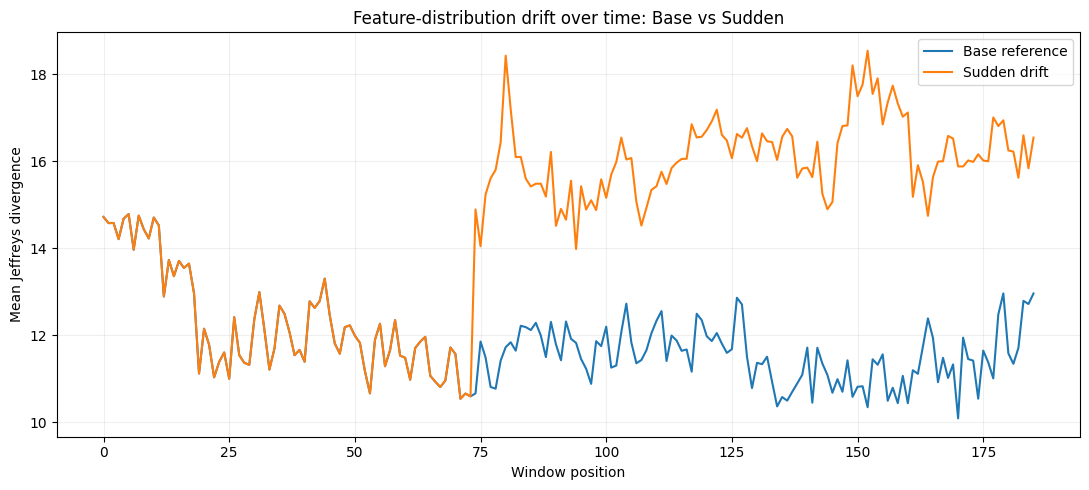

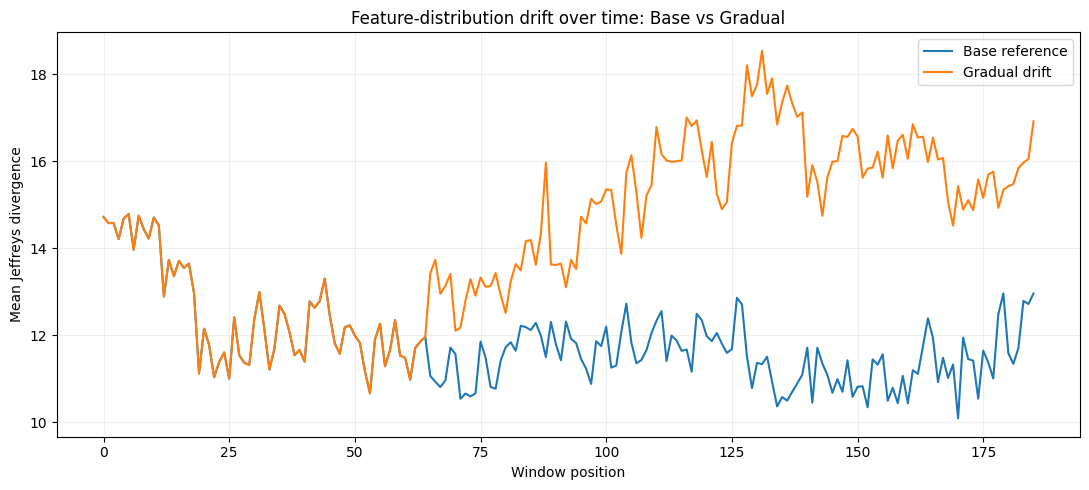

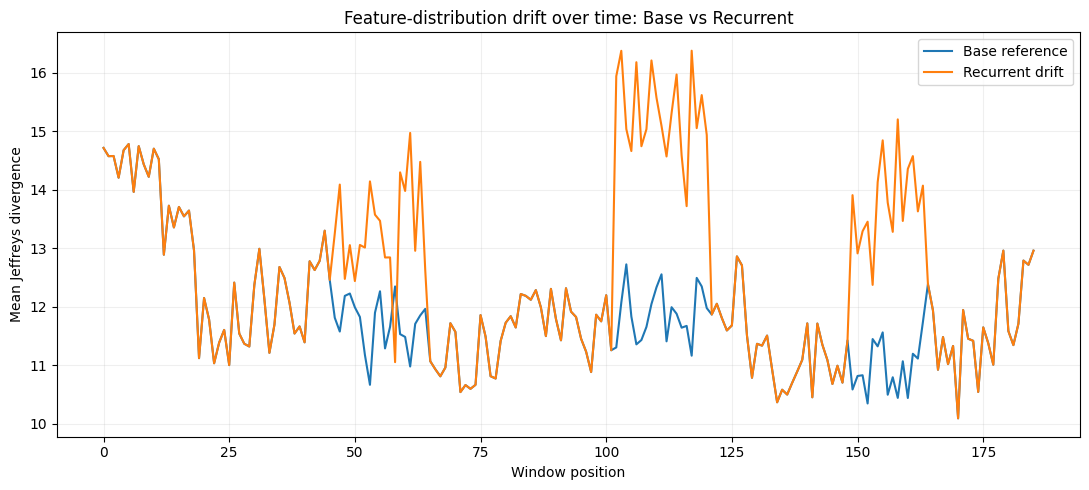

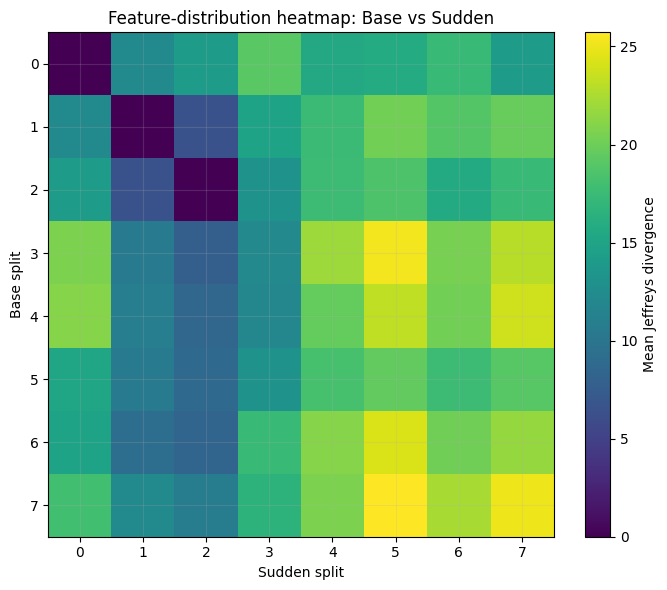

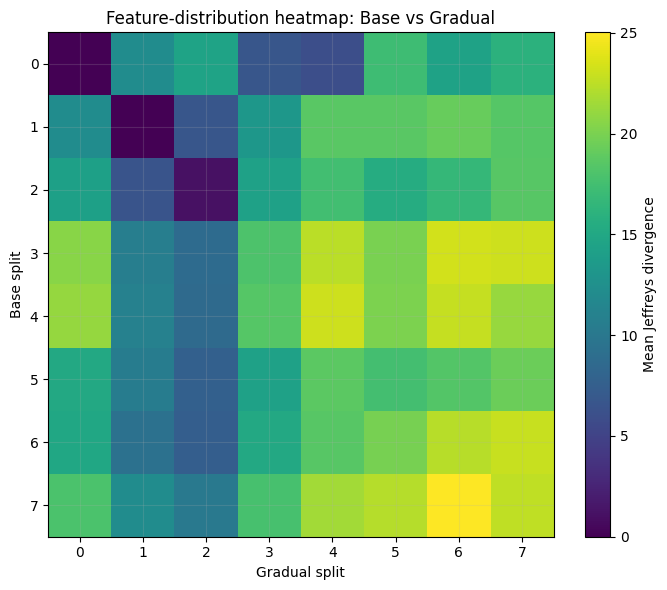

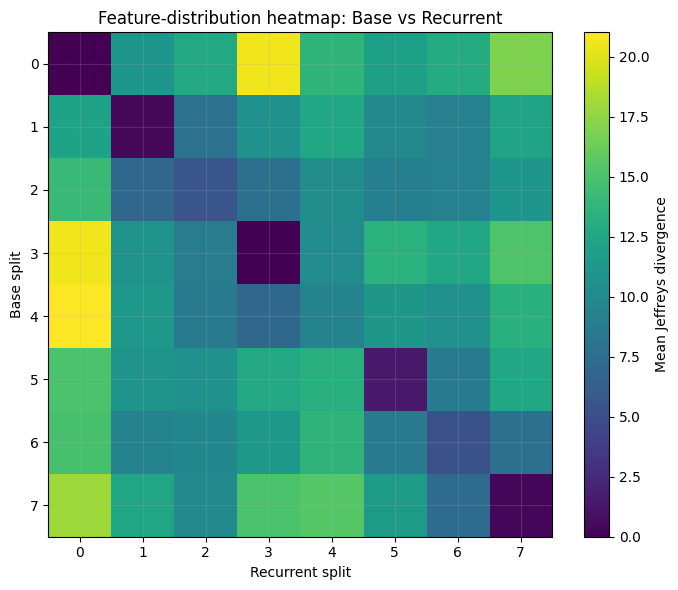

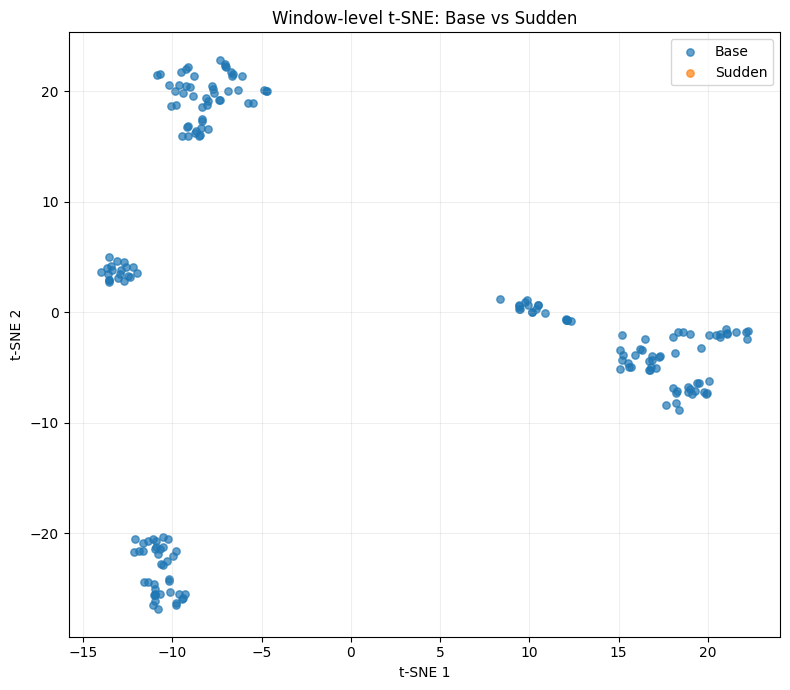

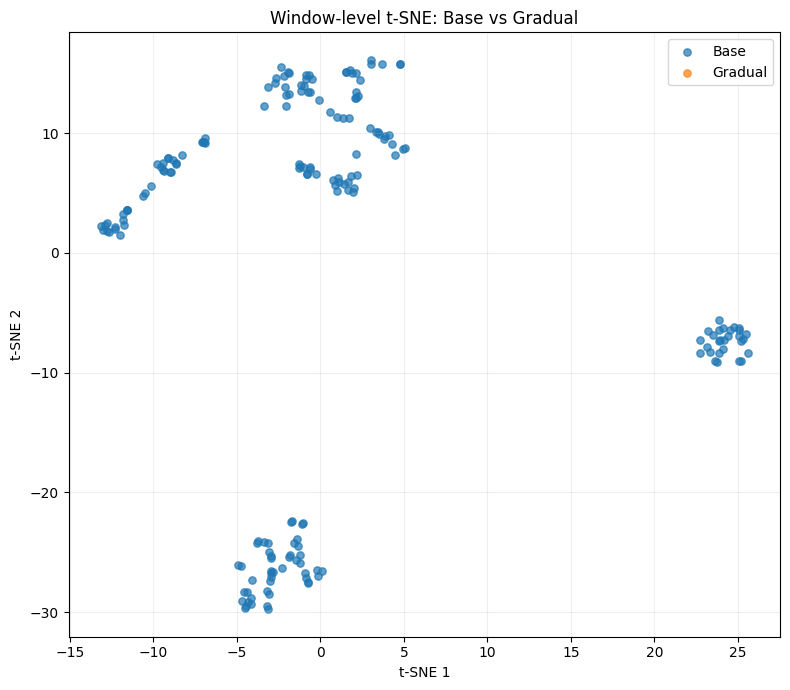

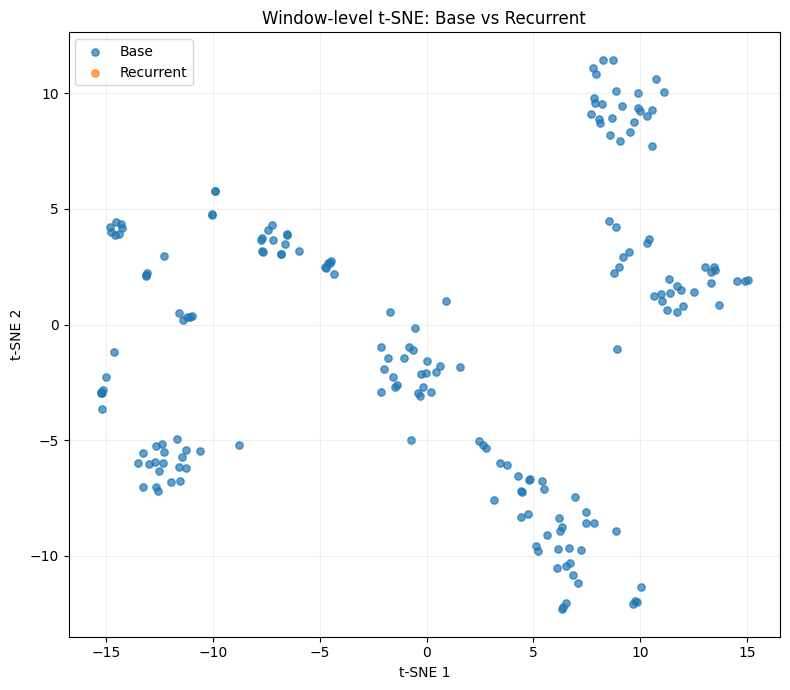

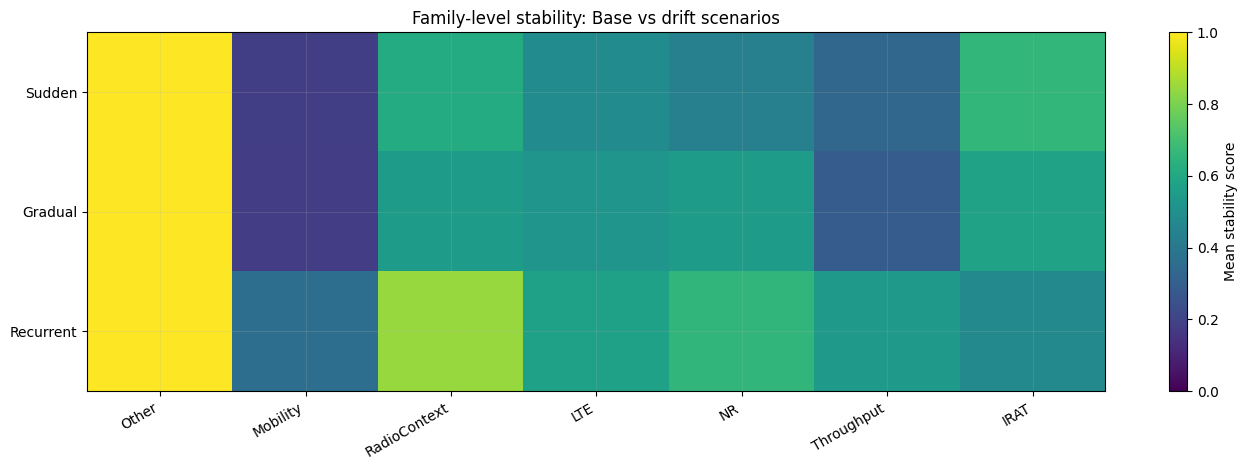

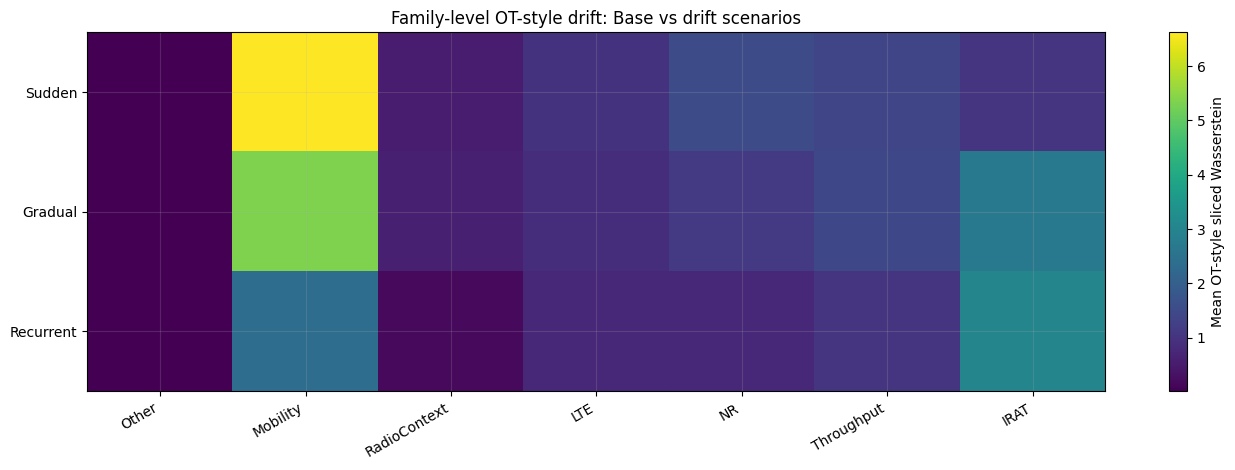

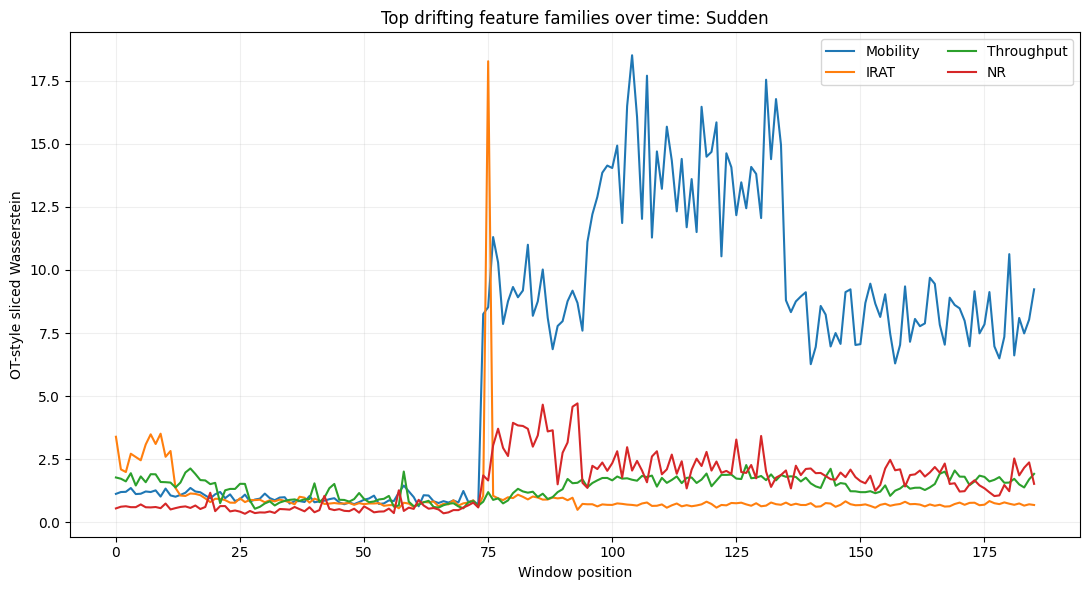

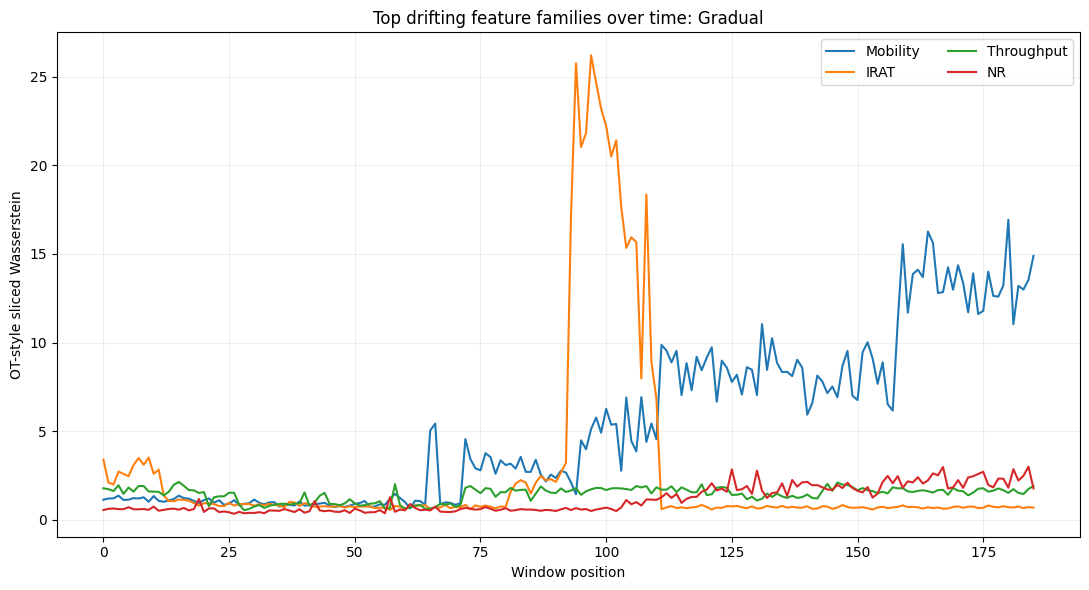

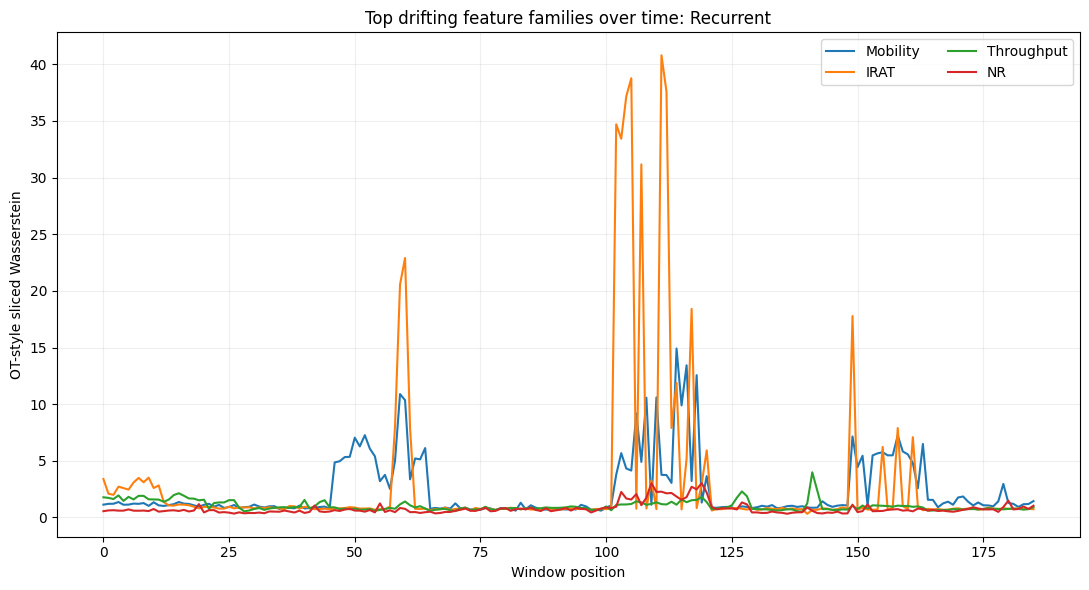

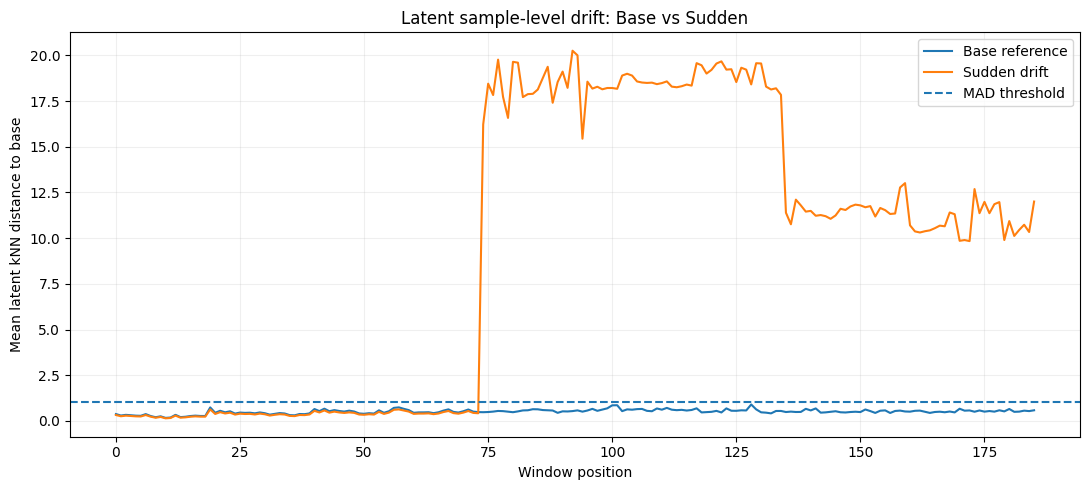

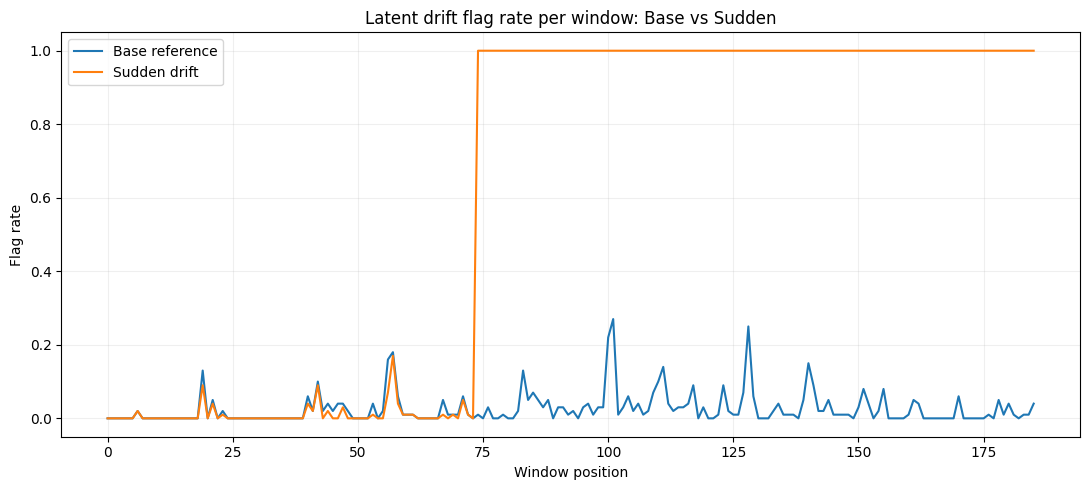

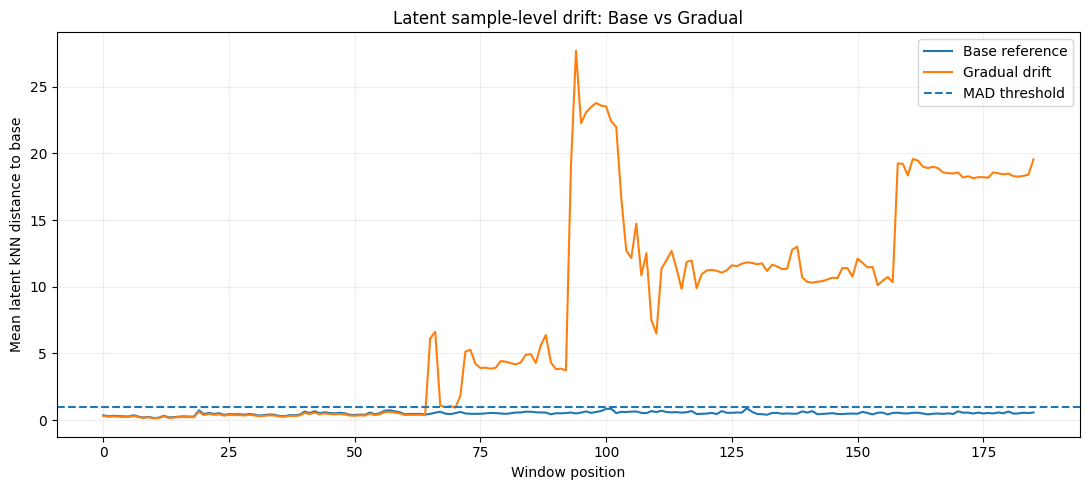

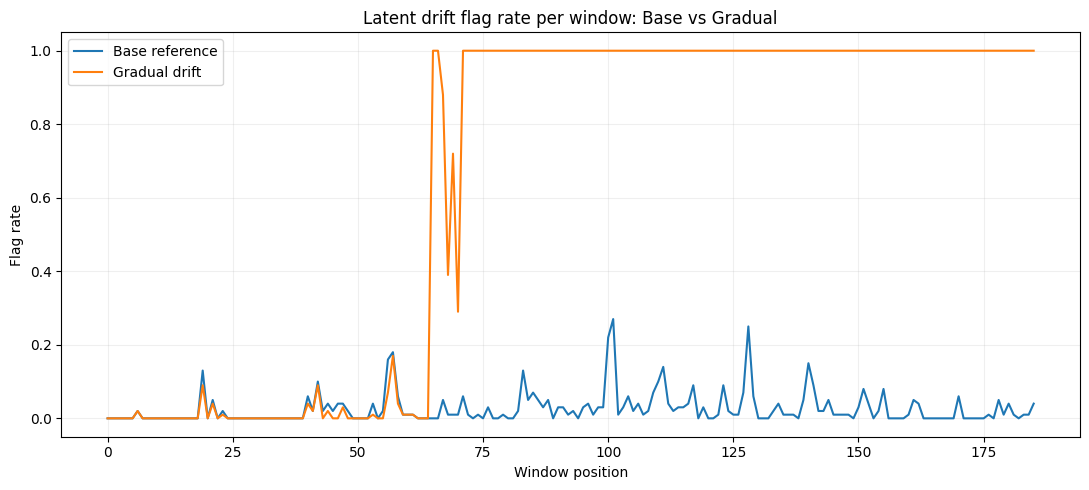

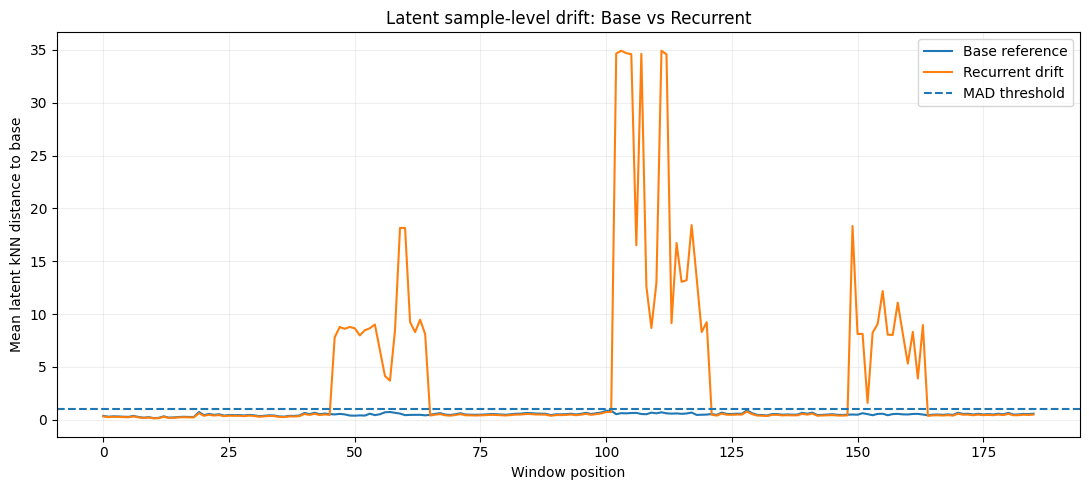

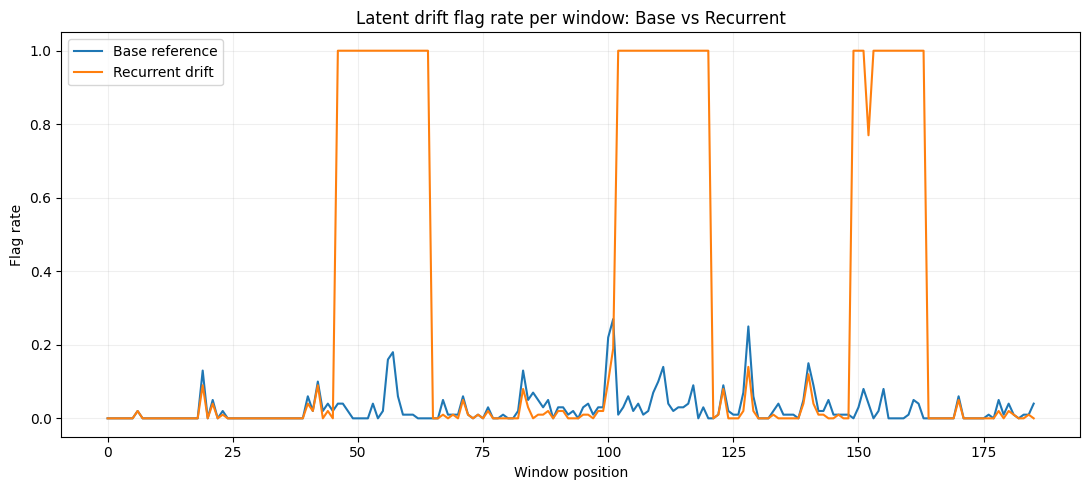


Saved outputs to: C:\Users\aen593\Desktop\network project\code\temp\drift_measurement_outputs

Drift summary:
 scenario  mean_jeffreys  mean_latent_score  mean_latent_flag_rate top_family_by_ot  top_family_ot
   Sudden      14.598229           9.312104               0.606237         Mobility       6.620967
  Gradual      14.363974           8.124778               0.644946         Mobility       5.342771
Recurrent      12.583394           4.031620               0.292312             IRAT       3.014690


In [1]:
%run drift_measurement.py
